# PyTorch で MNIST を学習するチュートリアル

このノートブックでは、PyTorch で MNIST 分類器を学習する流れを一通り実行します。

- データセットを用意する
- 畳み込みニューラルネットワークを定義する
- 学習と評価を 1 epoch 以上まわす
- 予測結果を確認する

In [1]:
from pathlib import Path

import torch
from IPython.display import display
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

In [2]:
batch_size = 128
epochs = 1
learning_rate = 1e-3
data_dir = Path("data")
num_workers = 0
seed = 42

In [3]:
def build_dataloaders(
    batch_size: int,
    data_dir: str | Path = "data",
    *,
    num_workers: int = 0,
    pin_memory: bool = False,
) -> tuple[DataLoader, DataLoader]:
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
        ]
    )

    root = Path(data_dir)
    train_dataset = datasets.MNIST(root=str(root), train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root=str(root), train=False, download=True, transform=transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
    )
    return train_loader, test_loader

In [4]:
class MnistClassifier(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.25),
            nn.Linear(128, 10),
        )

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.network(inputs)


def resolve_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps = getattr(torch.backends, "mps", None)
    if mps is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def train_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: Adam,
    device: torch.device,
) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for inputs, targets in data_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = loss_fn(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == targets).sum().item()
        total_samples += inputs.size(0)

    return total_loss / total_samples, total_correct / total_samples


@torch.inference_mode()
def evaluate(
    model: nn.Module,
    data_loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for inputs, targets in data_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        logits = model(inputs)
        loss = loss_fn(logits, targets)

        total_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        total_correct += (predictions == targets).sum().item()
        total_samples += inputs.size(0)

    return total_loss / total_samples, total_correct / total_samples


def format_metrics(prefix: str, loss: float, accuracy: float) -> str:
    return f"{prefix}: loss={loss:.4f} accuracy={accuracy:.2%}"

In [5]:
set_seed(seed)
device = resolve_device()
train_loader, test_loader = build_dataloaders(
    batch_size=batch_size,
    data_dir=data_dir,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)

print(f"Using device: {device}")
print(f"Train batches: {len(train_loader)}, test batches: {len(test_loader)}")

Using device: cuda
Train batches: 469, test batches: 79


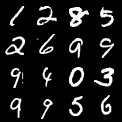

Labels: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4, 0, 3, 9, 9, 5, 6]


In [6]:
sample_images, sample_labels = next(iter(train_loader))
grid = utils.make_grid(sample_images[:16], nrow=4, normalize=True)
display(transforms.ToPILImage()(grid))
print("Labels:", sample_labels[:16].tolist())

In [ ]:
model = MnistClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=learning_rate)

model

In [ ]:
history = []

for epoch in range(1, epochs + 1):
    train_loss, train_accuracy = train_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_accuracy = evaluate(model, test_loader, loss_fn, device)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
    }
    history.append(row)
    print(f"Epoch {epoch}/{epochs}")
    print(format_metrics("  train", train_loss, train_accuracy))
    print(format_metrics("  test ", test_loss, test_accuracy))

history

In [ ]:
with torch.inference_mode():
    logits = model(sample_images[:16].to(device))

predictions = logits.argmax(dim=1).cpu().tolist()
list(zip(sample_labels[:16].tolist(), predictions))